<a href="https://www.kaggle.com/code/ziadhamadafathy/predict-house-price-using-rfs-gradient-boosting?scriptVersionId=99576810" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Importing Libraries

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.feature_selection import SelectPercentile
from sklearn.feature_selection import chi2 , f_classif 
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


# Preparing data and Cleaning it

In [2]:
df = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


To know number of null value in each column

In [3]:
null_columns=df.columns[df.isnull().any()]
df[null_columns].isnull().sum()

LotFrontage      259
Alley           1369
MasVnrType         8
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

To know percent of null value in each column

In [4]:
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageYrBlt,81,0.055479
GarageCond,81,0.055479
GarageType,81,0.055479
GarageFinish,81,0.055479


we dropped this columns because contain a lot of null values

In [5]:
df.drop(columns=['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu'], inplace=True)

To know number of null values in remaining columns

In [6]:
null_columns=df.columns[df.isnull().any()]
df[null_columns].isnull().sum()

LotFrontage     259
MasVnrType        8
MasVnrArea        8
BsmtQual         37
BsmtCond         37
BsmtExposure     38
BsmtFinType1     37
BsmtFinType2     38
Electrical        1
GarageType       81
GarageYrBlt      81
GarageFinish     81
GarageQual       81
GarageCond       81
dtype: int64

Know the types of columns values to we will separate numerical columns about categorical columns

In [7]:
df[null_columns].dtypes

LotFrontage     float64
MasVnrType       object
MasVnrArea      float64
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
BsmtFinType2     object
Electrical       object
GarageType       object
GarageYrBlt     float64
GarageFinish     object
GarageQual       object
GarageCond       object
dtype: object

We Use KNNImputer in numerical columns to fill in missing values in a dataset using the k-Nearest Neighbors method 

In [8]:
cleaner = KNNImputer(n_neighbors=10, weights="distance")
numerical = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
df[numerical] = cleaner.fit_transform(df[numerical])

In [9]:
null_columns=df.columns[df.isnull().any()]
df[null_columns].isnull().sum()

MasVnrType       8
BsmtQual        37
BsmtCond        37
BsmtExposure    38
BsmtFinType1    37
BsmtFinType2    38
Electrical       1
GarageType      81
GarageFinish    81
GarageQual      81
GarageCond      81
dtype: int64

By using ColumnTransformer, we fill the missing values by using mode

In [10]:
categorical = df[null_columns].select_dtypes(include = "object").columns
cleaner = ColumnTransformer([
    ('categorical_transformer', SimpleImputer(strategy='most_frequent'), categorical)
])
df[null_columns] = cleaner.fit_transform(df[null_columns])

To make sure that no null values in dataset

In [11]:
null_columns=df.columns[df.isnull().any()]
df[null_columns].isnull().sum()

Series([], dtype: float64)

To convert all categorical columns to numerical

In [12]:
object_data = df.select_dtypes(include=['object'])
#to convert data of object type to numbers
encoder = preprocessing.LabelEncoder()
for i in range(object_data.shape[1]):
    object_data.iloc[:, i] = encoder.fit_transform(object_data.iloc[:, i])

#concat between data none object and data object after convert it
num_data = df.select_dtypes(exclude=['object'])
df = pd.concat([object_data, num_data], axis=1)

/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1951: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[selected_item_labels] = value
/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1773: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


Display dataset after labeling

In [13]:
df

,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,3,1,3,3,0,4,0,5,2,2,...,0,61,0,0,0,0,0,2,2008,208500
1,3,1,3,3,0,2,0,24,1,2,...,298,0,0,0,0,0,0,5,2007,181500
2,3,1,0,3,0,4,0,5,2,2,...,0,42,0,0,0,0,0,9,2008,223500
3,3,1,0,3,0,0,0,6,2,2,...,0,35,272,0,0,0,0,2,2006,140000
4,3,1,0,3,0,2,0,15,2,2,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,3,1,3,3,0,4,0,8,2,2,...,0,40,0,0,0,0,0,8,2007,175000
1456,3,1,3,3,0,4,0,14,2,2,...,349,0,0,0,0,0,0,2,2010,210000
1457,3,1,3,3,0,4,0,6,2,2,...,0,60,0,0,0,0,2500,5,2010,266500
1458,3,1,3,3,0,4,0,12,2,2,...,366,0,112,0,0,0,0,4,2010,142125


We won't use all columns in dataset but we will use the most influential columns in SalePrice

In [14]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1] 

FeatureSelection = SelectPercentile(score_func = chi2, percentile=50) # score_func can = f_classif
X = FeatureSelection.fit_transform(X, y)

#showing X Dimension 
print('X Shape is ' , X.shape)

X Shape is  (1460, 37)


# Correlation among features

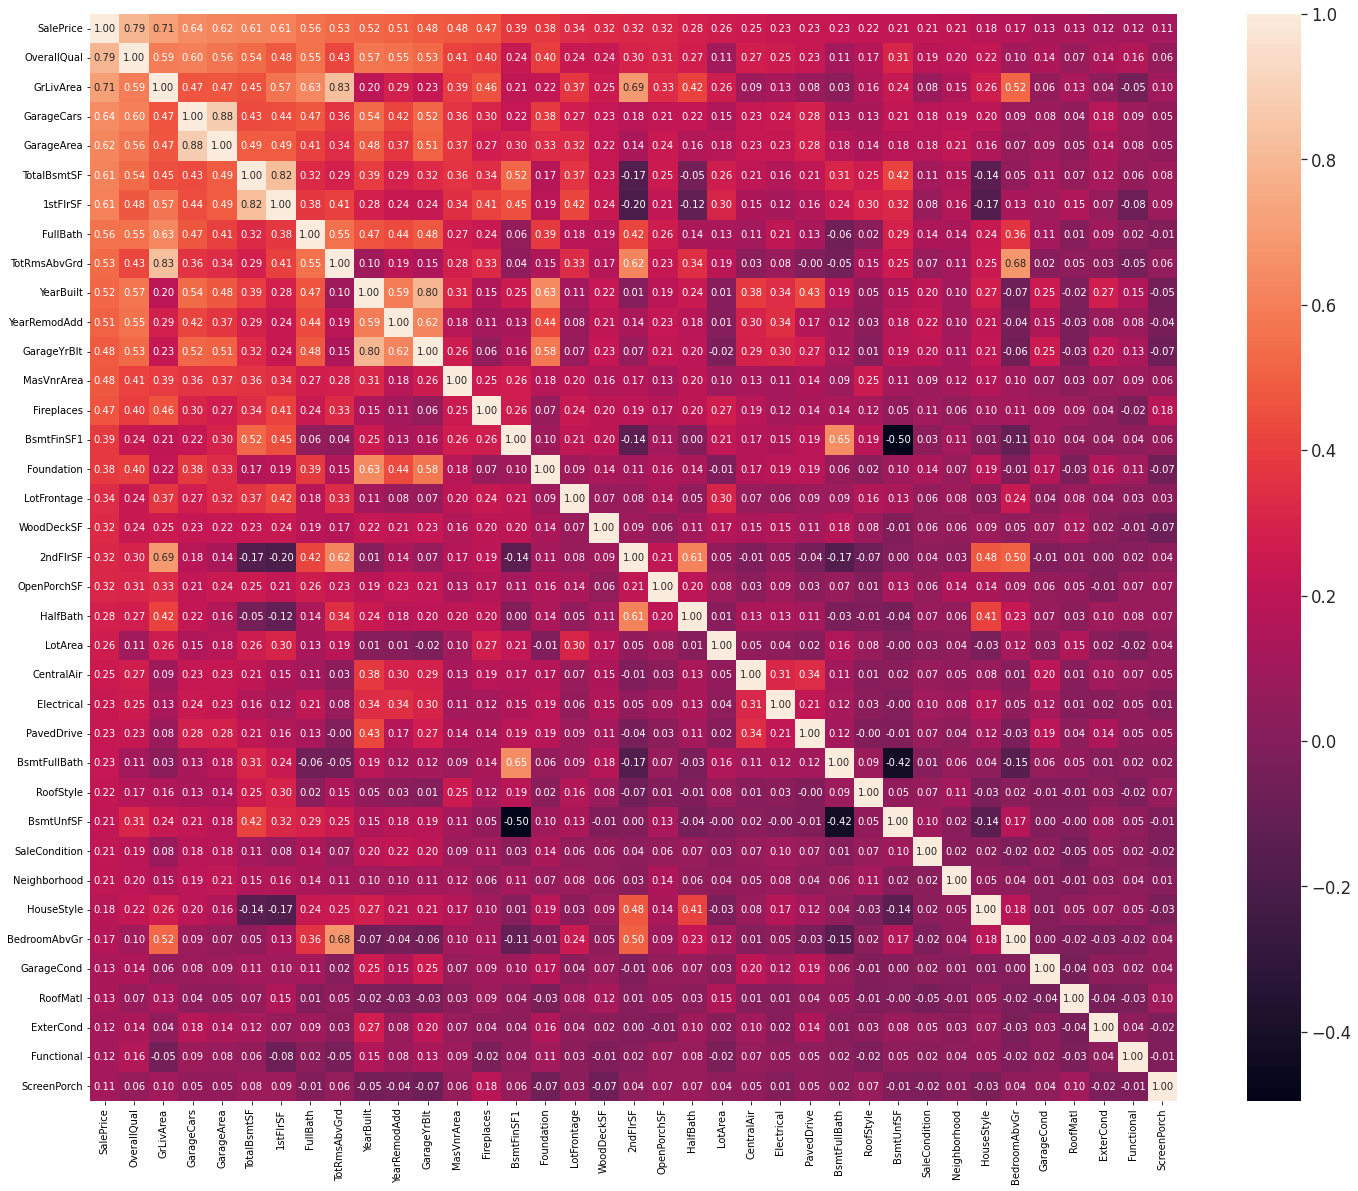

In [15]:
corrmat = df.corr()
f, ax = plt.subplots(figsize=(25, 20))
cols = corrmat.nlargest(37, 'SalePrice')['SalePrice'].index
cm = np.corrcoef(df[cols].values.T)
sns.set(font_scale=1.5)
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

<AxesSubplot:xlabel='SalePrice', ylabel='Count'>

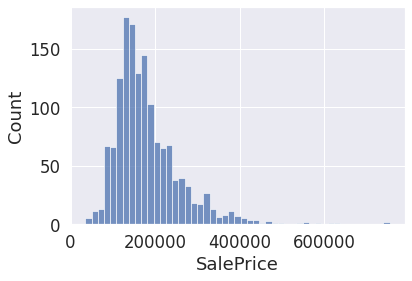

In [16]:
sns.histplot(df['SalePrice'])

In [17]:
data = df[cols]
data

,SalePrice,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,...,BsmtUnfSF,SaleCondition,Neighborhood,HouseStyle,BedroomAbvGr,GarageCond,RoofMatl,ExterCond,Functional,ScreenPorch
0,208500,7,1710,2,548,856,856,2,8,2003,...,150,4,5,5,3,4,1,4,6,0
1,181500,6,1262,2,460,1262,1262,2,6,1976,...,284,4,24,2,3,4,1,4,6,0
2,223500,7,1786,2,608,920,920,2,6,2001,...,434,4,5,5,3,4,1,4,6,0
3,140000,7,1717,3,642,756,961,1,7,1915,...,540,0,6,5,3,4,1,4,6,0
4,250000,8,2198,3,836,1145,1145,2,9,2000,...,490,4,15,5,4,4,1,4,6,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,175000,6,1647,2,460,953,953,2,7,1999,...,953,4,8,5,3,4,1,4,6,0
1456,210000,6,2073,2,500,1542,2073,2,7,1978,...,589,4,14,2,3,4,1,4,2,0
1457,266500,7,2340,1,252,1152,1188,2,9,1941,...,877,4,6,5,4,4,1,2,6,0
1458,142125,5,1078,1,240,1078,1078,1,5,1950,...,0,4,12,2,2,4,1,4,6,0


# Spliting data

In [18]:
X = data.iloc[:, 1:]
y = data.iloc[:, 0]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=44, shuffle =True)

# GradientBoostingRegressor Model

In [19]:
GBRModel = GradientBoostingRegressor(n_estimators=300,max_depth=3,learning_rate = 0.1,random_state=0)
GBRModel.fit(X_train, y_train)
print('GBRModel Train Score is : ' , GBRModel.score(X_train, y_train))
print('GBRModel Test Score is : ' , GBRModel.score(X_test, y_test))

GBRModel Train Score is :  0.9861026995368377
GBRModel Test Score is :  0.8933297898456811


In [20]:
y_pred_gbr = GBRModel.predict(X_test)
print('Predicted Value for Gradient Boosting Regressor is : \n' , (y_pred_gbr[:10]))
print('Actual Value for Gradient Boosting Regressor is : \n' , y_test[:10] )

Predicted Value for Gradient Boosting Regressor is : 
 [120346.02532758 150525.64378288 330261.49333664 130426.73143225
 147823.90275672 156119.8119982  142801.73486233 199322.39424732
 160369.11735067 213791.79488461]
Actual Value for Gradient Boosting Regressor is : 
 1140    139000
132     150750
642     345000
952     133900
1297    140000
1399    137450
360     156000
849     187000
1073    159500
1057    248000
Name: SalePrice, dtype: int64


# RandomForestRegressor Model

In [21]:
RandomForestRegressorModel = RandomForestRegressor(max_features='sqrt',bootstrap=True,max_depth=10,n_estimators=100,
                                                   criterion='absolute_error',random_state=44)
RandomForestRegressorModel.fit(X_train, y_train)
print('Random Forest Regressor Train Score is : ' , RandomForestRegressorModel.score(X_train, y_train))
print('Random Forest Regressor Test Score is : ' , RandomForestRegressorModel.score(X_test, y_test))

Random Forest Regressor Train Score is :  0.9699620520709747
Random Forest Regressor Test Score is :  0.8714977118423841


In [22]:
y_pred_rf = RandomForestRegressorModel.predict(X_test)
print('Predicted Value for Random Forest Regressor Model is : \n' , y_pred_rf[:10])
print('Actual Value for Gradient Boosting Regressor is : \n' , y_test[:10])

Predicted Value for Random Forest Regressor Model is : 
 [123809.45  145915.315 291467.12  124302.59  154710.19  144014.2
 141313.6   179475.305 156465.6   213034.945]
Actual Value for Gradient Boosting Regressor is : 
 1140    139000
132     150750
642     345000
952     133900
1297    140000
1399    137450
360     156000
849     187000
1073    159500
1057    248000
Name: SalePrice, dtype: int64


# submission

In [23]:
test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')
test.drop(columns=['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu'], inplace=True)

In [24]:
null_columns=test.columns[test.isnull().any()]
test[null_columns].isnull().sum()

MSZoning          4
LotFrontage     227
Utilities         2
Exterior1st       1
Exterior2nd       1
MasVnrType       16
MasVnrArea       15
BsmtQual         44
BsmtCond         45
BsmtExposure     44
BsmtFinType1     42
BsmtFinSF1        1
BsmtFinType2     42
BsmtFinSF2        1
BsmtUnfSF         1
TotalBsmtSF       1
BsmtFullBath      2
BsmtHalfBath      2
KitchenQual       1
Functional        2
GarageType       76
GarageYrBlt      78
GarageFinish     78
GarageCars        1
GarageArea        1
GarageQual       78
GarageCond       78
SaleType          1
dtype: int64

In [25]:
test[null_columns].dtypes

MSZoning         object
LotFrontage     float64
Utilities        object
Exterior1st      object
Exterior2nd      object
MasVnrType       object
MasVnrArea      float64
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
BsmtFinSF1      float64
BsmtFinType2     object
BsmtFinSF2      float64
BsmtUnfSF       float64
TotalBsmtSF     float64
BsmtFullBath    float64
BsmtHalfBath    float64
KitchenQual      object
Functional       object
GarageType       object
GarageYrBlt     float64
GarageFinish     object
GarageCars      float64
GarageArea      float64
GarageQual       object
GarageCond       object
SaleType         object
dtype: object

In [26]:
cleaner = KNNImputer(n_neighbors=10, weights="distance")
numerical = ['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 
             'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea']
test[numerical] = cleaner.fit_transform(test[numerical])

In [27]:
null_columns=test.columns[test.isnull().any()]
test[null_columns].isnull().sum()

MSZoning         4
Utilities        2
Exterior1st      1
Exterior2nd      1
MasVnrType      16
BsmtQual        44
BsmtCond        45
BsmtExposure    44
BsmtFinType1    42
BsmtFinType2    42
KitchenQual      1
Functional       2
GarageType      76
GarageFinish    78
GarageQual      78
GarageCond      78
SaleType         1
dtype: int64

In [28]:
categorical_test = test[null_columns].select_dtypes(include = "object").columns
cleaner = ColumnTransformer([
    ('categorical_transformer', SimpleImputer(strategy='most_frequent'), categorical_test)
])
test[categorical_test] = cleaner.fit_transform(test[null_columns])

In [29]:
null_columns=test.columns[test.isnull().any()]
test[null_columns].isnull().sum()

Series([], dtype: float64)

In [30]:
object_data_test = test.select_dtypes(include=['object'])
#to convert data of object type to numbers
encoder = preprocessing.LabelEncoder()
for i in range(object_data_test.shape[1]):
    object_data_test.iloc[:, i] = encoder.fit_transform(object_data_test.iloc[:, i])

#concat between data none object and data object after convert it
num_data_test = test.select_dtypes(exclude=['object'])
test = pd.concat([object_data_test, num_data_test], axis=1)

/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1951: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.obj[selected_item_labels] = value
/opt/conda/lib/python3.7/site-packages/pandas/core/indexing.py:1773: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(ilocs[0], value, pi)


In [31]:
cols_test = cols.drop(['SalePrice'])

In [32]:
data_test = test[cols_test]
data_test

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,...,BsmtUnfSF,SaleCondition,Neighborhood,HouseStyle,BedroomAbvGr,GarageCond,RoofMatl,ExterCond,Functional,ScreenPorch
0,5,896,1.0,730.0,882.0,896,1,5,1961,1961,...,270.0,4,12,2,2,4,0,4,6,120
1,6,1329,1.0,312.0,1329.0,1329,1,6,1958,1958,...,406.0,4,12,2,3,4,0,4,6,0
2,5,1629,2.0,482.0,928.0,928,2,6,1997,1998,...,137.0,4,8,4,3,4,0,4,6,0
3,6,1604,2.0,470.0,926.0,926,2,7,1998,1998,...,324.0,4,8,4,3,4,0,4,6,0
4,8,1280,2.0,506.0,1280.0,1280,2,5,1992,1992,...,1017.0,4,22,2,2,4,0,4,6,144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,4,1092,0.0,0.0,546.0,546,1,5,1970,1970,...,546.0,4,10,4,3,4,0,4,6,0
1455,4,1092,1.0,286.0,546.0,546,1,6,1970,1970,...,294.0,0,10,4,3,4,0,4,6,0
1456,5,1224,2.0,576.0,1224.0,1224,1,7,1960,1996,...,0.0,0,11,2,4,4,0,4,6,0
1457,5,970,0.0,0.0,912.0,970,1,6,1992,1992,...,575.0,4,11,5,3,4,0,4,6,0


In [33]:
x_test = data_test.iloc[:]
y_pred_gbr = GBRModel.predict(x_test)
y_pred_rf = RandomForestRegressorModel.predict(x_test)

In [34]:
test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')
submission = test[["Id"]]
submission["SalePrice"] = y_pred_rf 

submission.to_csv('my_output_rf.csv', index=False)
submission["SalePrice"] = y_pred_gbr 
submission.to_csv('my_output_gbr.csv', index=False)


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
